# レストラン来客数予測 - Kaggle提出用ノートブック

## Recruit Restaurant Visitor Forecasting

**コンペティション**: https://www.kaggle.com/c/recruit-restaurant-visitor-forecasting  
**評価指標**: RMSLE (Root Mean Squared Logarithmic Error)  
**目標**: 日本のレストランの将来の来客数を予測する

### ノートブック構成
1. データ読み込みと概要把握
2. 探索的データ分析 (EDA)
3. 特徴量エンジニアリング
4. モデル学習 (LightGBM)
5. 予測と提出ファイル生成

---
## 1. セットアップとデータ読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 50)

# 乱数シード固定
SEED = 42
np.random.seed(SEED)

INPUT_DIR = Path('../input')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

print('セットアップ完了')

セットアップ完了


In [2]:
# 全データ読み込み
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_store = pd.read_csv(INPUT_DIR / 'hpg_store_info.csv')
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])
submission = pd.read_csv(INPUT_DIR / 'sample_submission.csv')

print(f'来客データ:     {air_visit.shape}')
print(f'Air予約データ:  {air_reserve.shape}')
print(f'HPG予約データ:  {hpg_reserve.shape}')
print(f'Air店舗情報:    {air_store.shape}')
print(f'HPG店舗情報:    {hpg_store.shape}')
print(f'店舗紐付け:     {store_relation.shape}')
print(f'日付情報:       {date_info.shape}')
print(f'提出サンプル:   {submission.shape}')

来客データ:     (252108, 3)
Air予約データ:  (92378, 4)
HPG予約データ:  (2000320, 4)
Air店舗情報:    (829, 5)
HPG店舗情報:    (4690, 5)
店舗紐付け:     (150, 2)
日付情報:       (517, 3)
提出サンプル:   (32019, 2)


---
## 2. 探索的データ分析 (EDA)

### 2.1 来客データの概要

In [3]:
print('=== 来客データ ===')
print(air_visit.describe())
print(f'\n店舗数: {air_visit["air_store_id"].nunique()}')
print(f'期間: {air_visit["visit_date"].min()} ～ {air_visit["visit_date"].max()}')
print(f'来客数の中央値: {air_visit["visitors"].median():.0f}')
print(f'来客数の平均値: {air_visit["visitors"].mean():.1f}')

=== 来客データ ===
                          visit_date       visitors
count                         252108  252108.000000
mean   2016-10-12 12:49:04.566614528      20.973761
min              2016-01-01 00:00:00       1.000000
25%              2016-07-23 00:00:00       9.000000
50%              2016-10-23 00:00:00      17.000000
75%              2017-01-24 00:00:00      29.000000
max              2017-04-22 00:00:00     877.000000
std                              NaN      16.757007

店舗数: 829
期間: 2016-01-01 00:00:00 ～ 2017-04-22 00:00:00
来客数の中央値: 17
来客数の平均値: 21.0


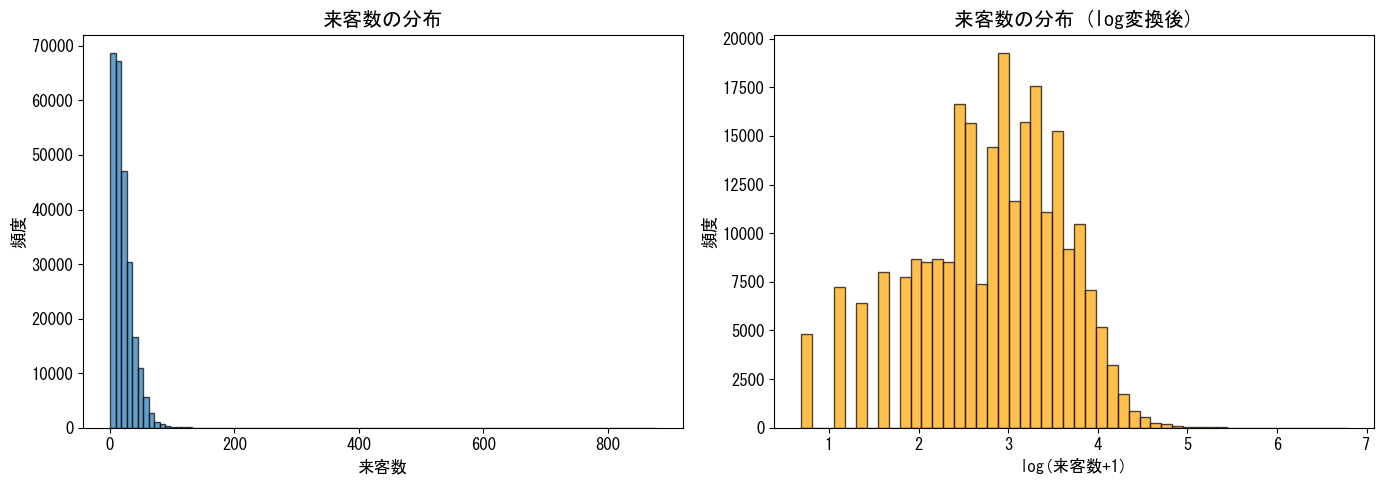

→ log変換後は正規分布に近い形になる。RMSLEはlog空間での誤差を測るため、これは重要な性質。


In [4]:
# 来客数の分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(air_visit['visitors'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('来客数の分布')
axes[0].set_xlabel('来客数')
axes[0].set_ylabel('頻度')

axes[1].hist(np.log1p(air_visit['visitors']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('来客数の分布 (log変換後)')
axes[1].set_xlabel('log(来客数+1)')
axes[1].set_ylabel('頻度')

plt.tight_layout()
plt.show()

print('→ log変換後は正規分布に近い形になる。RMSLEはlog空間での誤差を測るため、これは重要な性質。')

### 2.2 曜日・月ごとのパターン

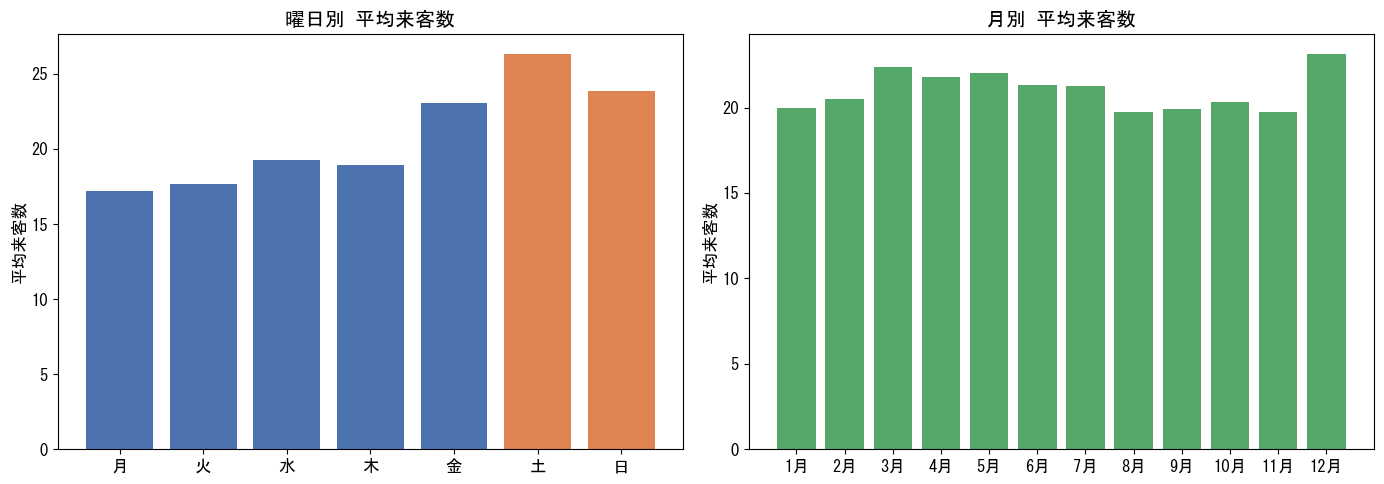

→ 金曜・土曜に来客が多い。12月は忘年会シーズンでピーク。


In [5]:
# 曜日ごとの来客数
air_visit['dow'] = air_visit['visit_date'].dt.dayofweek
dow_names = ['月', '火', '水', '木', '金', '土', '日']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_stats = air_visit.groupby('dow')['visitors'].mean()
axes[0].bar(range(7), dow_stats.values, color=['#4C72B0']*5 + ['#DD8452']*2)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_names)
axes[0].set_title('曜日別 平均来客数')
axes[0].set_ylabel('平均来客数')

# 月ごとの来客数
air_visit['month'] = air_visit['visit_date'].dt.month
month_stats = air_visit.groupby('month')['visitors'].mean()
axes[1].bar(range(1, 13), month_stats.values, color='#55A868')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'{m}月' for m in range(1, 13)])
axes[1].set_title('月別 平均来客数')
axes[1].set_ylabel('平均来客数')

plt.tight_layout()
plt.show()

print('→ 金曜・土曜に来客が多い。12月は忘年会シーズンでピーク。')

### 2.3 店舗ジャンル分析

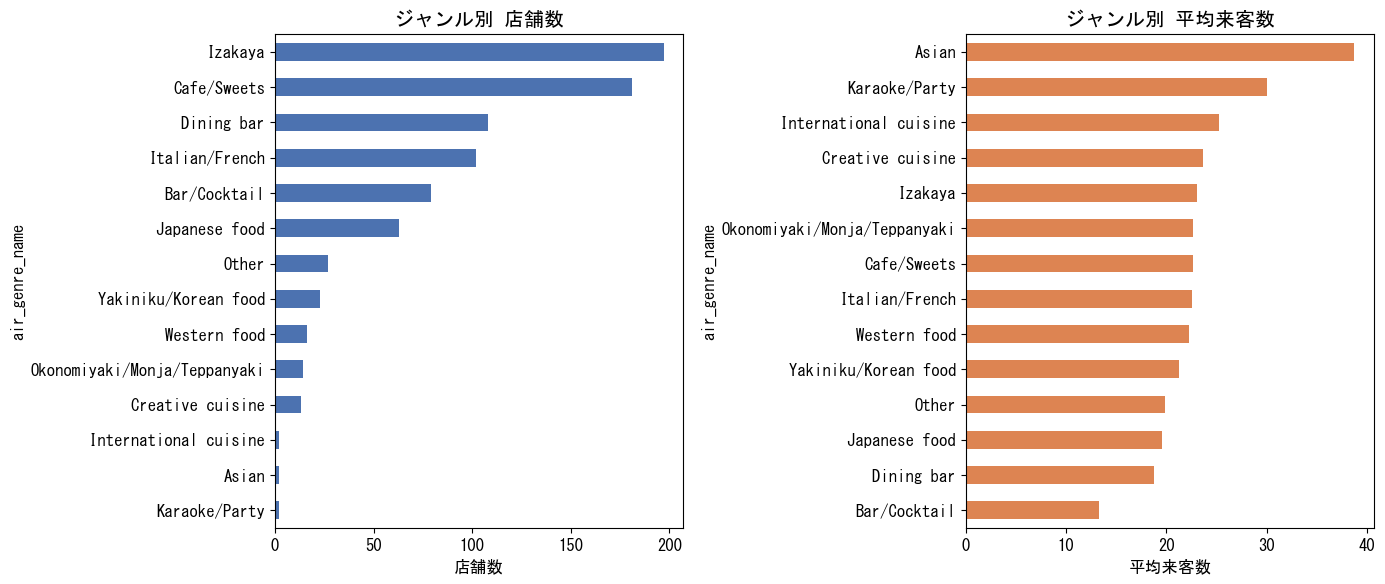

In [6]:
# ジャンル別の店舗数と平均来客数
genre_count = air_store['air_genre_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

genre_count.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('ジャンル別 店舗数')
axes[0].set_xlabel('店舗数')
axes[0].invert_yaxis()

# ジャンル別の平均来客数
merged = air_visit.merge(air_store[['air_store_id', 'air_genre_name']], on='air_store_id')
genre_visitors = merged.groupby('air_genre_name')['visitors'].mean().sort_values(ascending=True)
genre_visitors.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('ジャンル別 平均来客数')
axes[1].set_xlabel('平均来客数')

plt.tight_layout()
plt.show()

### 2.4 祝日の影響

In [7]:
# 祝日 vs 平日の来客数比較
visit_with_holiday = air_visit.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

holiday_stats = visit_with_holiday.groupby('holiday_flg')['visitors'].agg(['mean', 'median', 'std'])
holiday_stats.index = ['平日', '祝日']
print('=== 祝日 vs 平日 ===')
print(holiday_stats.round(2))
print(f'\n祝日は平日と比べて来客数が {(holiday_stats.loc["祝日", "mean"] / holiday_stats.loc["平日", "mean"] - 1) * 100:.1f}% 多い')

=== 祝日 vs 平日 ===
     mean  median    std
平日  20.83    17.0  16.62
祝日  23.70    19.0  18.86

祝日は平日と比べて来客数が 13.8% 多い


### 2.5 提出データの確認

In [8]:
# 提出データの解析
# IDフォーマット: air_{hash}_{date} → split('_')で3要素
submission['air_store_id'] = submission['id'].apply(lambda x: x.rsplit('_', 1)[0])
submission['visit_date'] = pd.to_datetime(submission['id'].apply(lambda x: x.rsplit('_', 1)[1]))

print(f'予測対象店舗数: {submission["air_store_id"].nunique()}')
print(f'予測期間: {submission["visit_date"].min()} ～ {submission["visit_date"].max()}')
print(f'予測レコード数: {len(submission)}')

# 学習データに含まれない店舗があるか確認
train_stores = set(air_visit['air_store_id'].unique())
test_stores = set(submission['air_store_id'].unique())
print(f'\n学習データの店舗数: {len(train_stores)}')
print(f'テストデータの店舗数: {len(test_stores)}')
print(f'テストにのみ存在する店舗: {len(test_stores - train_stores)}')

予測対象店舗数: 821
予測期間: 2017-04-23 00:00:00 ～ 2017-05-31 00:00:00
予測レコード数: 32019

学習データの店舗数: 829
テストデータの店舗数: 821
テストにのみ存在する店舗: 0


---
## 3. 特徴量エンジニアリング

上位解法に基づき、以下の特徴量を作成する:
- 時間特徴量 (曜日、月、祝日)
- Rolling統計量 (過去N日の平均、標準偏差)
- ラグ特徴量 (N日前の来客数)
- 予約情報特徴量
- 店舗統計量

### 3.1 学習用データの構築

In [9]:
# テストデータの構築（提出用）
test_df = submission[['air_store_id', 'visit_date']].copy()
test_df['visitors'] = np.nan

# 学習データ
train_df = air_visit[['air_store_id', 'visit_date', 'visitors']].copy()

# 結合して全データを作成
all_df = pd.concat([train_df, test_df], ignore_index=True)
all_df = all_df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)

print(f'全データ: {all_df.shape}')
print(f'  学習: {train_df.shape[0]}')
print(f'  テスト: {test_df.shape[0]}')

全データ: (284127, 3)
  学習: 252108
  テスト: 32019


### 3.2 時間特徴量

In [10]:
# 時間特徴量
all_df['year'] = all_df['visit_date'].dt.year
all_df['month'] = all_df['visit_date'].dt.month
all_df['day'] = all_df['visit_date'].dt.day
all_df['dow'] = all_df['visit_date'].dt.dayofweek  # 0=月曜
all_df['week'] = all_df['visit_date'].dt.isocalendar().week.astype(int)
all_df['is_weekend'] = (all_df['dow'] >= 5).astype(int)

# 祝日情報の結合
all_df = all_df.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)
all_df['is_holiday'] = all_df['holiday_flg'].fillna(0).astype(int)

# 祝日の前日フラグ（前日は来客増加の傾向）
date_info_sorted = date_info.sort_values('calendar_date')
date_info_sorted['is_before_holiday'] = date_info_sorted['holiday_flg'].shift(-1).fillna(0).astype(int)
all_df = all_df.merge(
    date_info_sorted[['calendar_date', 'is_before_holiday']].rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)
all_df['is_before_holiday'] = all_df['is_before_holiday'].fillna(0).astype(int)

print(f'時間特徴量を追加: {all_df.shape}')

時間特徴量を追加: (284127, 13)


### 3.3 店舗情報特徴量

In [11]:
# 店舗情報を結合
all_df = all_df.merge(air_store, on='air_store_id', how='left')

# カテゴリ変数をエンコード
all_df['genre_encoded'] = all_df['air_genre_name'].factorize()[0]
all_df['area_encoded'] = all_df['air_area_name'].factorize()[0]

# エリアから都道府県を抽出
all_df['prefecture'] = all_df['air_area_name'].apply(lambda x: x.split(' ')[0] if pd.notna(x) else 'unknown')
all_df['prefecture_encoded'] = all_df['prefecture'].factorize()[0]

print(f'店舗情報を追加: {all_df.shape}')
print(f'ジャンル数: {all_df["air_genre_name"].nunique()}')
print(f'エリア数: {all_df["air_area_name"].nunique()}')

店舗情報を追加: (284127, 21)
ジャンル数: 14
エリア数: 103


### 3.4 店舗別統計量

各店舗の過去データから統計量を計算する。テストデータにも適用できるよう、学習データのみから算出する。

In [12]:
# 店舗別の統計量（学習データのみから算出）
store_stats = train_df.groupby('air_store_id')['visitors'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).reset_index()
store_stats.columns = ['air_store_id', 'store_mean', 'store_median', 'store_std',
                        'store_min', 'store_max', 'store_count']

all_df = all_df.merge(store_stats, on='air_store_id', how='left')

# 店舗×曜日の統計量
train_with_dow = train_df.copy()
train_with_dow['dow'] = train_with_dow['visit_date'].dt.dayofweek
store_dow_stats = train_with_dow.groupby(['air_store_id', 'dow'])['visitors'].agg([
    'mean', 'median', 'std'
]).reset_index()
store_dow_stats.columns = ['air_store_id', 'dow', 'store_dow_mean', 'store_dow_median', 'store_dow_std']

all_df = all_df.merge(store_dow_stats, on=['air_store_id', 'dow'], how='left')

# ジャンル別統計量（新規店舗向けのフォールバック）
genre_stats = train_df.merge(air_store[['air_store_id', 'air_genre_name']], on='air_store_id')
genre_stats = genre_stats.groupby('air_genre_name')['visitors'].agg(['mean', 'median']).reset_index()
genre_stats.columns = ['air_genre_name', 'genre_mean', 'genre_median']

all_df = all_df.merge(genre_stats, on='air_genre_name', how='left')

print(f'店舗統計量を追加: {all_df.shape}')

店舗統計量を追加: (284127, 32)


### 3.5 予約情報特徴量

AirとHPG両方の予約データを活用する。HPGの予約データはstore_id_relationを使ってAir店舗IDに紐付ける。

In [13]:
# Air予約データの集計
air_reserve['visit_date'] = air_reserve['visit_datetime'].dt.date
air_reserve['visit_date'] = pd.to_datetime(air_reserve['visit_date'])
air_reserve['reserve_date'] = air_reserve['reserve_datetime'].dt.date
air_reserve['reserve_date'] = pd.to_datetime(air_reserve['reserve_date'])
air_reserve['days_before'] = (air_reserve['visit_date'] - air_reserve['reserve_date']).dt.days

air_res_agg = air_reserve.groupby(['air_store_id', 'visit_date']).agg(
    air_reserve_visitors=('reserve_visitors', 'sum'),
    air_reserve_count=('reserve_visitors', 'count'),
    air_reserve_mean_days=('days_before', 'mean')
).reset_index()

# HPG予約データをAir店舗IDに変換して集計
hpg_reserve['visit_date'] = hpg_reserve['visit_datetime'].dt.date
hpg_reserve['visit_date'] = pd.to_datetime(hpg_reserve['visit_date'])
hpg_reserve['reserve_date'] = hpg_reserve['reserve_datetime'].dt.date
hpg_reserve['reserve_date'] = pd.to_datetime(hpg_reserve['reserve_date'])
hpg_reserve['days_before'] = (hpg_reserve['visit_date'] - hpg_reserve['reserve_date']).dt.days

# HPG→Air IDの紐付け
hpg_reserve = hpg_reserve.merge(store_relation, on='hpg_store_id', how='inner')

hpg_res_agg = hpg_reserve.groupby(['air_store_id', 'visit_date']).agg(
    hpg_reserve_visitors=('reserve_visitors', 'sum'),
    hpg_reserve_count=('reserve_visitors', 'count'),
    hpg_reserve_mean_days=('days_before', 'mean')
).reset_index()

# データに結合
all_df = all_df.merge(air_res_agg, on=['air_store_id', 'visit_date'], how='left')
all_df = all_df.merge(hpg_res_agg, on=['air_store_id', 'visit_date'], how='left')

# 予約合計
all_df['total_reserve_visitors'] = all_df['air_reserve_visitors'].fillna(0) + all_df['hpg_reserve_visitors'].fillna(0)
all_df['total_reserve_count'] = all_df['air_reserve_count'].fillna(0) + all_df['hpg_reserve_count'].fillna(0)

print(f'予約情報を追加: {all_df.shape}')
print(f'Air予約あり: {all_df["air_reserve_visitors"].notna().sum()} / {len(all_df)}')
print(f'HPG予約あり: {all_df["hpg_reserve_visitors"].notna().sum()} / {len(all_df)}')

予約情報を追加: (284127, 40)
Air予約あり: 29195 / 284127
HPG予約あり: 13880 / 284127


### 3.6 Rolling統計量とラグ特徴量

**注意**: データリークを防ぐため、必ず `.shift(1)` してからrollingを計算する。テスト期間は来客実績がないため、学習データの最後の値を使って計算する。

In [14]:
# 日付でソートし、欠損日を0で補完した完全なデータを作成
# （Rolling統計量を正確に計算するため）

all_stores = all_df['air_store_id'].unique()
min_date = all_df['visit_date'].min()
max_date = all_df['visit_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

# 全店舗×全日付のグリッド
grid = pd.MultiIndex.from_product([all_stores, all_dates], names=['air_store_id', 'visit_date'])
grid_df = pd.DataFrame(index=grid).reset_index()

# 来客数を結合（テスト期間と営業していない日はNaN）
grid_df = grid_df.merge(
    train_df[['air_store_id', 'visit_date', 'visitors']],
    on=['air_store_id', 'visit_date'],
    how='left'
)

print(f'グリッドデータ: {grid_df.shape}')

グリッドデータ: (428593, 3)


In [15]:
# Rolling統計量の計算
windows = [7, 14, 21, 35, 63]

grid_df = grid_df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)

for w in windows:
    grouped = grid_df.groupby('air_store_id')['visitors']
    grid_df[f'rolling_mean_{w}'] = grouped.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean()
    )
    grid_df[f'rolling_std_{w}'] = grouped.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).std()
    )
    grid_df[f'rolling_max_{w}'] = grouped.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).max()
    )
    grid_df[f'rolling_min_{w}'] = grouped.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).min()
    )

# 指数加重平均
grid_df['ewm_mean'] = grid_df.groupby('air_store_id')['visitors'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)

print(f'Rolling特徴量を計算: {grid_df.shape[1]} 列')

Rolling特徴量を計算: 24 列


In [16]:
# ラグ特徴量
lags = [1, 7, 14, 21, 28, 35]

for lag in lags:
    grid_df[f'lag_{lag}'] = grid_df.groupby('air_store_id')['visitors'].shift(lag)

print(f'ラグ特徴量を追加: {grid_df.shape[1]} 列')

ラグ特徴量を追加: 30 列


In [17]:
# Rolling/ラグ特徴量をメインデータに結合
rolling_cols = [c for c in grid_df.columns if c.startswith(('rolling_', 'ewm_', 'lag_'))]

all_df = all_df.merge(
    grid_df[['air_store_id', 'visit_date'] + rolling_cols],
    on=['air_store_id', 'visit_date'],
    how='left'
)

print(f'最終データ: {all_df.shape}')
print(f'\n特徴量一覧:')
for col in sorted(all_df.columns):
    print(f'  {col}')

最終データ: (284127, 67)

特徴量一覧:
  air_area_name
  air_genre_name
  air_reserve_count
  air_reserve_mean_days
  air_reserve_visitors
  air_store_id
  area_encoded
  day
  day_of_week
  dow
  ewm_mean
  genre_encoded
  genre_mean
  genre_median
  holiday_flg
  hpg_reserve_count
  hpg_reserve_mean_days
  hpg_reserve_visitors
  is_before_holiday
  is_holiday
  is_weekend
  lag_1
  lag_14
  lag_21
  lag_28
  lag_35
  lag_7
  latitude
  longitude
  month
  prefecture
  prefecture_encoded
  rolling_max_14
  rolling_max_21
  rolling_max_35
  rolling_max_63
  rolling_max_7
  rolling_mean_14
  rolling_mean_21
  rolling_mean_35
  rolling_mean_63
  rolling_mean_7
  rolling_min_14
  rolling_min_21
  rolling_min_35
  rolling_min_63
  rolling_min_7
  rolling_std_14
  rolling_std_21
  rolling_std_35
  rolling_std_63
  rolling_std_7
  store_count
  store_dow_mean
  store_dow_median
  store_dow_std
  store_max
  store_mean
  store_median
  store_min
  store_std
  total_reserve_count
  total_reserve_visitors

---
## 4. モデル学習

上位解法で最も使われているLightGBMを使用する。

### 方針
- 目的変数はlog変換 → RMSLEの最適化に直結
- 時系列バリデーション: 2017年3月のデータで検証
- 特徴量選択: 重要度の低い特徴量は除外

In [18]:
# RMSLE評価関数
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error"""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

In [19]:
# 特徴量の定義
FEATURE_COLS = [
    # 時間特徴量
    'month', 'day', 'dow', 'week', 'is_weekend', 'is_holiday', 'is_before_holiday',
    # 店舗特徴量
    'genre_encoded', 'area_encoded', 'prefecture_encoded',
    'latitude', 'longitude',
    # 店舗統計量
    'store_mean', 'store_median', 'store_std', 'store_min', 'store_max', 'store_count',
    'store_dow_mean', 'store_dow_median', 'store_dow_std',
    'genre_mean', 'genre_median',
    # 予約情報
    'air_reserve_visitors', 'air_reserve_count',
    'hpg_reserve_visitors', 'hpg_reserve_count',
    'total_reserve_visitors', 'total_reserve_count',
    # Rolling統計量
    'rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7',
    'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14',
    'rolling_mean_21', 'rolling_std_21', 'rolling_max_21', 'rolling_min_21',
    'rolling_mean_35', 'rolling_std_35', 'rolling_max_35', 'rolling_min_35',
    'rolling_mean_63', 'rolling_std_63', 'rolling_max_63', 'rolling_min_63',
    'ewm_mean',
    # ラグ特徴量
    'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35',
]

TARGET = 'visitors'

# 学習/テスト分割
is_train = all_df[TARGET].notna()
train = all_df[is_train].copy()
test = all_df[~is_train].copy()

print(f'学習データ: {train.shape}')
print(f'テストデータ: {test.shape}')
print(f'使用特徴量数: {len(FEATURE_COLS)}')

学習データ: (252108, 67)
テストデータ: (32019, 67)
使用特徴量数: 56


### 4.1 バリデーション（時系列分割）

In [20]:
# 時系列分割: 最後の39日間（テスト期間と同じ長さ）を検証用に使う
VALID_START = '2017-03-12'

tr_mask = train['visit_date'] < VALID_START
va_mask = train['visit_date'] >= VALID_START

X_tr = train.loc[tr_mask, FEATURE_COLS]
y_tr = train.loc[tr_mask, TARGET]
X_va = train.loc[va_mask, FEATURE_COLS]
y_va = train.loc[va_mask, TARGET]

print(f'学習: {X_tr.shape} ({train.loc[tr_mask, "visit_date"].min()} ～ {train.loc[tr_mask, "visit_date"].max()})')
print(f'検証: {X_va.shape} ({train.loc[va_mask, "visit_date"].min()} ～ {train.loc[va_mask, "visit_date"].max()})')

学習: (222073, 56) (2016-01-01 00:00:00 ～ 2017-03-11 00:00:00)
検証: (30035, 56) (2017-03-12 00:00:00 ～ 2017-04-22 00:00:00)


In [21]:
# LightGBMパラメータ
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.02,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

# log変換した目的変数で学習
lgb_train = lgb.Dataset(X_tr, label=np.log1p(y_tr))
lgb_valid = lgb.Dataset(X_va, label=np.log1p(y_va), reference=lgb_train)

model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=3000,
    valid_sets=[lgb_train, lgb_valid],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=200)
    ]
)

# 検証スコア
va_pred = np.expm1(model.predict(X_va))
va_pred = np.clip(va_pred, 0, None)
va_score = rmsle(y_va, va_pred)

print(f'\n=====================================')
print(f'検証 RMSLE: {va_score:.5f}')
print(f'最適ラウンド数: {model.best_iteration}')
print(f'=====================================')

Training until validation scores don't improve for 100 rounds
[200]	training's rmse: 0.482951	valid_1's rmse: 0.481672
[400]	training's rmse: 0.470841	valid_1's rmse: 0.476293
[600]	training's rmse: 0.463548	valid_1's rmse: 0.475236
[800]	training's rmse: 0.457214	valid_1's rmse: 0.474674
[1000]	training's rmse: 0.45173	valid_1's rmse: 0.474403
[1200]	training's rmse: 0.446451	valid_1's rmse: 0.474162
[1400]	training's rmse: 0.441394	valid_1's rmse: 0.474034
[1600]	training's rmse: 0.436657	valid_1's rmse: 0.47394
Early stopping, best iteration is:
[1576]	training's rmse: 0.437213	valid_1's rmse: 0.473917

検証 RMSLE: 0.47392
最適ラウンド数: 1576


### 4.2 特徴量重要度

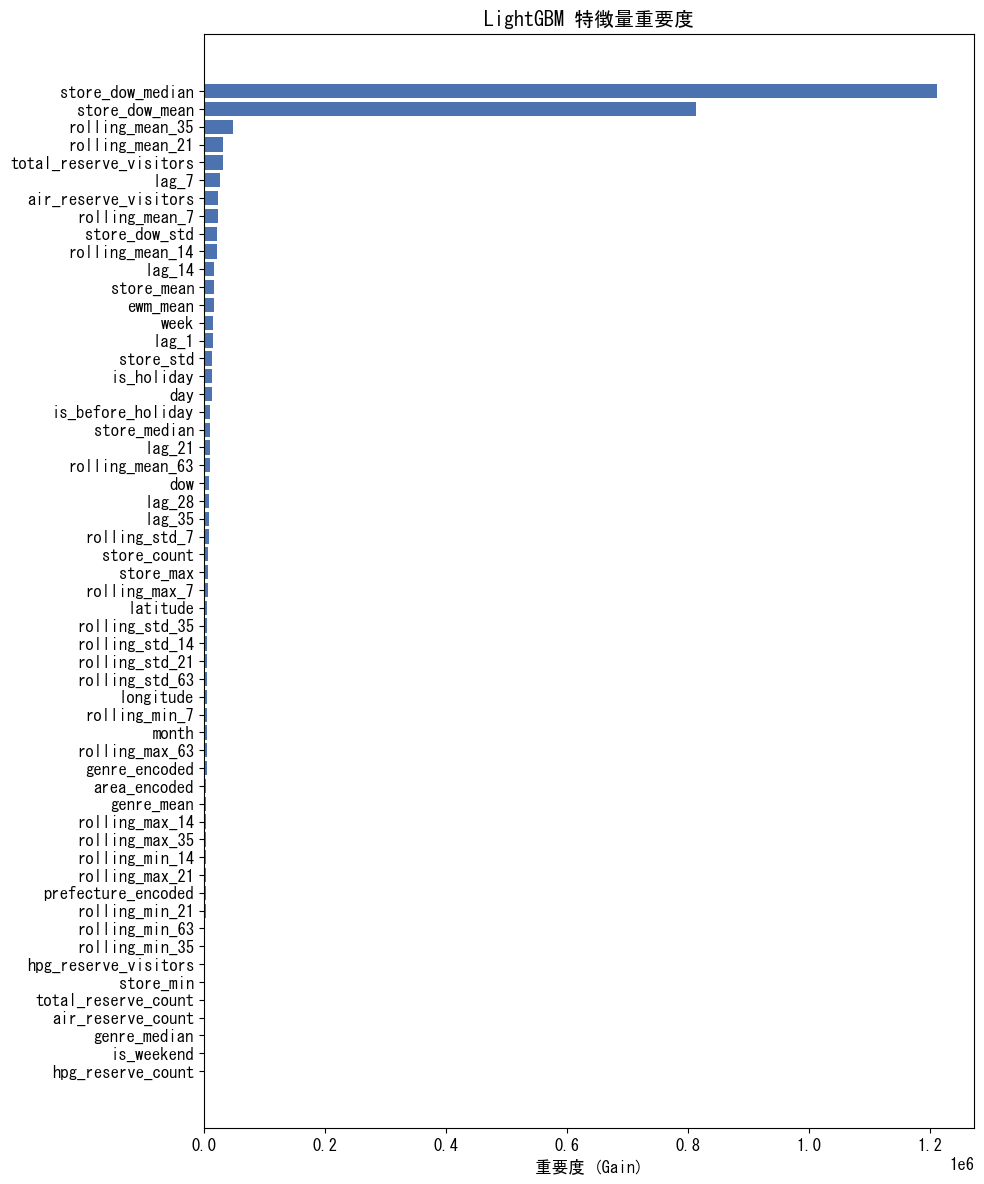


上位10特徴量:
  store_dow_median: 1211662
  store_dow_mean: 812899
  rolling_mean_35: 47394
  rolling_mean_21: 32049
  total_reserve_visitors: 31451
  lag_7: 26202
  air_reserve_visitors: 23461
  rolling_mean_7: 23277
  store_dow_std: 21948
  rolling_mean_14: 21100


In [22]:
# 特徴量重要度の可視化
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(importance['feature'], importance['importance'], color='#4C72B0')
ax.set_xlabel('重要度 (Gain)')
ax.set_title('LightGBM 特徴量重要度')
plt.tight_layout()
plt.show()

print('\n上位10特徴量:')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.0f}')

### 4.3 全学習データで再学習（提出用）

In [23]:
# 全学習データで最終モデルを学習
best_round = model.best_iteration

X_all_train = train[FEATURE_COLS]
y_all_train = train[TARGET]

lgb_full = lgb.Dataset(X_all_train, label=np.log1p(y_all_train))

final_model = lgb.train(
    lgb_params,
    lgb_full,
    num_boost_round=int(best_round * 1.1),  # 全データなので少し多めに
    callbacks=[lgb.log_evaluation(period=500)]
)

print(f'\n最終モデル学習完了 (ラウンド数: {int(best_round * 1.1)})')


最終モデル学習完了 (ラウンド数: 1733)


---
## 5. 予測と提出ファイル生成

In [24]:
# テストデータの予測
X_test = test[FEATURE_COLS]
test_pred = np.expm1(final_model.predict(X_test))
test_pred = np.clip(test_pred, 0, None)  # 負の値を0にクリップ

print(f'予測統計:')
print(f'  平均: {test_pred.mean():.1f}')
print(f'  中央値: {np.median(test_pred):.1f}')
print(f'  最小: {test_pred.min():.1f}')
print(f'  最大: {test_pred.max():.1f}')

予測統計:
  平均: 15.6
  中央値: 12.8
  最小: 0.8
  最大: 120.7


In [25]:
# 提出ファイルの作成
sub = submission[['id']].copy()

# テストデータとsubmissionの対応付け
test_with_id = test.copy()
test_with_id['id'] = test_with_id['air_store_id'] + '_' + test_with_id['visit_date'].dt.strftime('%Y-%m-%d')
test_with_id['visitors'] = test_pred

sub = sub.merge(test_with_id[['id', 'visitors']], on='id', how='left')

# 欠損値があればstore_meanで補完
missing = sub['visitors'].isna().sum()
if missing > 0:
    print(f'警告: {missing}件の欠損あり。店舗平均で補完します。')
    sub['air_store_id'] = sub['id'].apply(lambda x: x.rsplit('_', 1)[0])
    sub = sub.merge(store_stats[['air_store_id', 'store_mean']], on='air_store_id', how='left')
    sub['visitors'] = sub['visitors'].fillna(sub['store_mean']).fillna(train[TARGET].mean())
    sub = sub[['id', 'visitors']]

# 保存
output_path = OUTPUT_DIR / 'submission.csv'
sub.to_csv(output_path, index=False)

print(f'\n提出ファイルを保存: {output_path}')
print(f'レコード数: {len(sub)}')
print(f'\n先頭5行:')
sub.head()


提出ファイルを保存: ..\output\submission.csv
レコード数: 32019

先頭5行:


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,1.969742
1,air_00a91d42b08b08d9_2017-04-24,21.324072
2,air_00a91d42b08b08d9_2017-04-25,26.368018
3,air_00a91d42b08b08d9_2017-04-26,30.722623
4,air_00a91d42b08b08d9_2017-04-27,33.147600


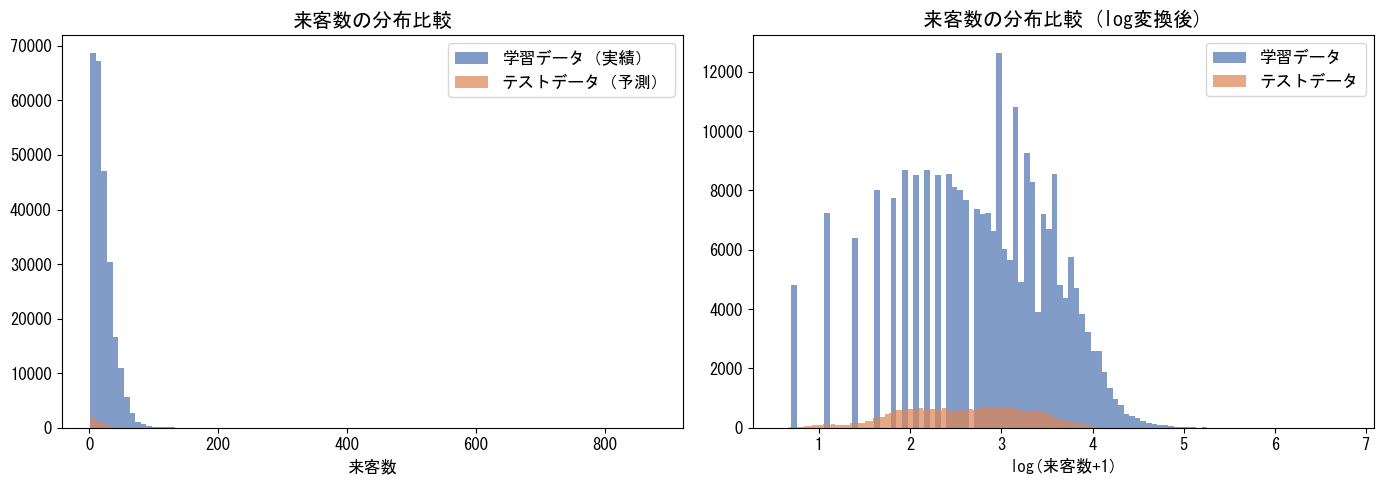

→ 学習データとテストデータの分布が大きく乖離していないことを確認


In [26]:
# 予測値の分布を確認
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train[TARGET], bins=100, alpha=0.7, label='学習データ（実績）', color='#4C72B0')
axes[0].hist(sub['visitors'], bins=100, alpha=0.7, label='テストデータ（予測）', color='#DD8452')
axes[0].set_title('来客数の分布比較')
axes[0].set_xlabel('来客数')
axes[0].legend()

axes[1].hist(np.log1p(train[TARGET]), bins=100, alpha=0.7, label='学習データ', color='#4C72B0')
axes[1].hist(np.log1p(sub['visitors']), bins=100, alpha=0.7, label='テストデータ', color='#DD8452')
axes[1].set_title('来客数の分布比較 (log変換後)')
axes[1].set_xlabel('log(来客数+1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('→ 学習データとテストデータの分布が大きく乖離していないことを確認')

---
## 6. まとめ

### 実施内容
1. **データ分析**: 8ファイルを統合し、来客パターン（曜日・月・祝日）を把握
2. **特徴量エンジニアリング**: 時間、店舗統計、予約情報、Rolling統計量、ラグ特徴量を作成
3. **モデル学習**: LightGBM（log変換目的変数 + early stopping）
4. **提出ファイル**: submission.csv を生成

### 検証スコア
- RMSLE: 上記セルの出力を参照

### 改善の方向性
- **アンサンブル**: XGBoost / CatBoost との加重平均
- **外部データ**: 天候データの追加（上位解法で効果あり）
- **特徴量追加**: 近隣店舗の来客数、イベント情報
- **ハイパーパラメータ最適化**: Optunaによるチューニング

In [27]:
print('=== 完了 ===')
print(f'提出ファイル: {OUTPUT_DIR / "submission.csv"}')
print(f'\nKaggle提出コマンド:')
print(f'kaggle competitions submit -c recruit-restaurant-visitor-forecasting -f {OUTPUT_DIR / "submission.csv"} -m "LightGBM with rolling features"')

=== 完了 ===
提出ファイル: ..\output\submission.csv

Kaggle提出コマンド:
kaggle competitions submit -c recruit-restaurant-visitor-forecasting -f ..\output\submission.csv -m "LightGBM with rolling features"
